# EXHALE solver-upgrade comparison

Visualizes the validation runs in `WASP-121b/solver_validation/`:
**Newton** (analytic-Jacobian ionization solve + Brent energy solve, the new
defaults) vs **hybrd1** (the legacy MINPACK solve, `ATES_FORCE_HYBRD1=1`) vs the
converged **baseline**. Both runs are a single post-process sweep over the
converged Case B, so they share an identical hydro state — the Newton-vs-hybrd1
difference is therefore the *pure solver* difference.

Regenerate the data with `bash run_validation.sh`; rebuild this notebook with
`python3 build_solver_nb.py`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

HERE = os.getcwd()
ION = ['HI','HII','HeI','HeII','HeIII','HeITR','CI','CII','CIII','OI','OII',
       'OIII','NI','NII','NIII','MgI','MgII','MgIII','SiI','SiII','SiIII','CaI',
       'CaII','CaIII','NaI','NaII','KI','KII','SI','SII','FeI','FeII','FeIII']
ICOL = {n: i+1 for i, n in enumerate(ION)}   # column index in Ion_species*.txt

def _sub(variant):
    return '' if variant == 'baseline' else 'output'

def hydro(variant, adv=False):
    f = 'Hydro_ioniz_adv.txt' if adv else 'Hydro_ioniz.txt'
    d = np.loadtxt(os.path.join(HERE, variant, _sub(variant), f))
    return dict(r=d[:,0], n=d[:,1], v=d[:,2], p=d[:,3], T=d[:,4],
                heat=d[:,5], cool=d[:,6])

def ion(variant, name, adv=False):
    f = 'Ion_species_adv.txt' if adv else 'Ion_species.txt'
    d = np.loadtxt(os.path.join(HERE, variant, _sub(variant), f))
    return d[:, ICOL[name]]

VAR = ['baseline', 'hybrd1', 'newton']
STY = {'baseline': dict(color='0.5', lw=3, alpha=0.6, label='baseline'),
       'hybrd1':   dict(color='tab:orange', lw=1.6, ls='--', label='hybrd1 (legacy)'),
       'newton':   dict(color='tab:blue', lw=1.2, label='Newton (new)')}
print('runs found:', [v for v in VAR if os.path.isdir(v)])

runs found: ['baseline', 'hybrd1', 'newton']


## 1. Profiles overlaid (they coincide)
Temperature, density, velocity and the key ion densities for the three runs. The
new (Newton) and legacy (hybrd1) curves lie on top of each other and on the
baseline, i.e. the upgraded solvers reproduce the original result.

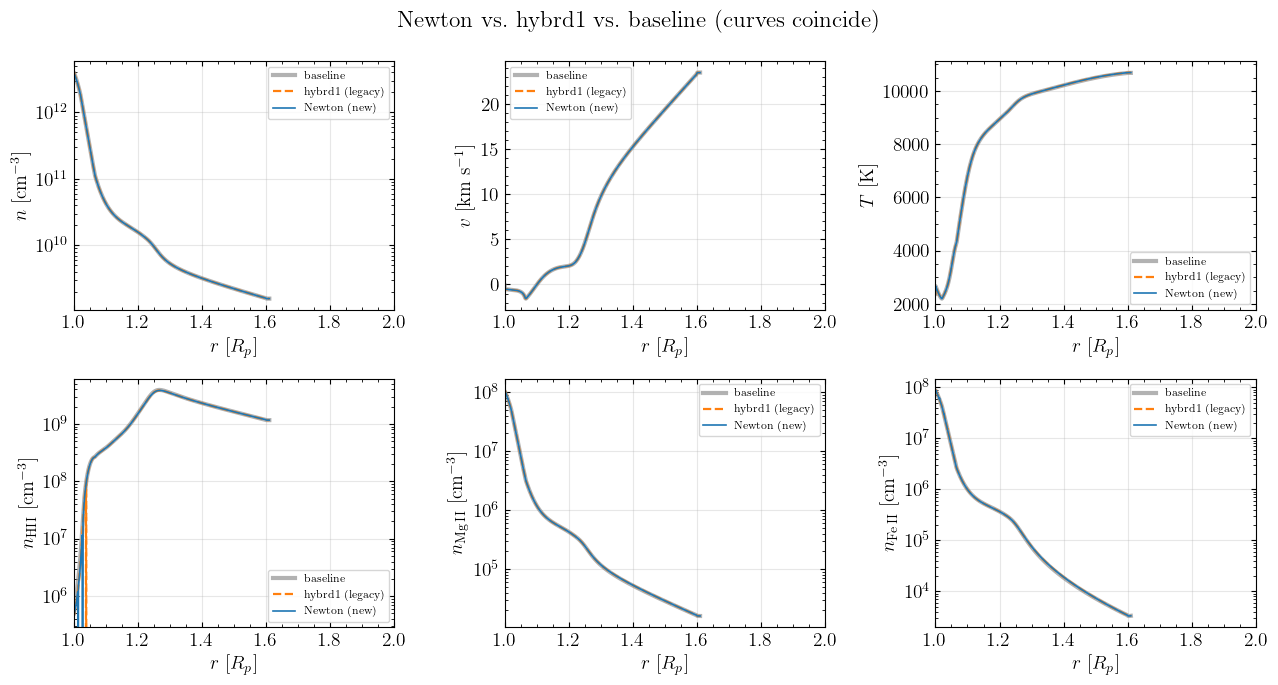

In [2]:
fig, ax = plt.subplots(2, 3, figsize=(13, 7))
for v in VAR:
    h = hydro(v)
    ax[0,0].semilogy(h['r'], h['n'], **STY[v]); ax[0,0].set_ylabel(r'$n$ [cm$^{-3}$]')
    ax[0,1].plot(h['r'], h['v']/1e5, **STY[v]); ax[0,1].set_ylabel(r'$v$ [km s$^{-1}$]')
    ax[0,2].plot(h['r'], h['T'], **STY[v]);     ax[0,2].set_ylabel(r'$T$ [K]')
    ax[1,0].semilogy(h['r'], ion(v,'HII'), **STY[v]); ax[1,0].set_ylabel(r'$n_{\rm HII}$ [cm$^{-3}$]')
    ax[1,1].semilogy(h['r'], ion(v,'MgII'), **STY[v]); ax[1,1].set_ylabel(r'$n_{\rm Mg\,II}$ [cm$^{-3}$]')
    ax[1,2].semilogy(h['r'], ion(v,'FeII'), **STY[v]); ax[1,2].set_ylabel(r'$n_{\rm Fe\,II}$ [cm$^{-3}$]')
for a in ax.flat:
    a.set_xlabel(r'$r$ [$R_p$]'); a.set_xlim(1, 2); a.grid(alpha=0.3); a.legend(fontsize=8)
fig.suptitle('Newton vs.\\ hybrd1 vs.\\ baseline (curves coincide)')
plt.tight_layout(); plt.show()

## 2. Pure solver difference: Newton $-$ hybrd1
Both share the identical one-step hydro state, so this is the solver-only
difference. The analytic-Jacobian Newton reproduces the MINPACK root to
$\sim10^{-6}$--$10^{-7}$ (relative) across temperature and all ion stages.

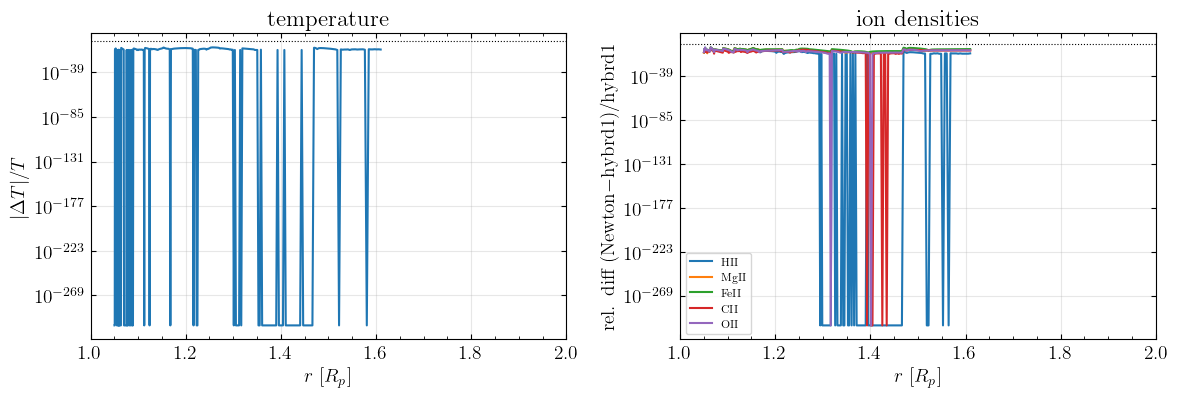

max ion rel diff over significant stages in [1.05,2] Rp: 7.19e-07
(trace stages near the base/ghost cells inflate a naive global metric; the physical-region number above is the meaningful one.)


In [3]:
hn, hh = hydro('newton'), hydro('hybrd1')
r = hn['r']
win = (r >= 1.05) & (r <= 2.0)   # physical wind / line-forming region
def reldiff(a, b):
    return np.abs(a-b)/np.maximum(np.abs(b), 1e-300)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].semilogy(r[win], reldiff(hn['T'], hh['T'])[win]+1e-300)
ax[0].set_ylabel(r'$|\Delta T|/T$'); ax[0].set_title('temperature')
for nm in ['HII', 'MgII', 'FeII', 'CII', 'OII']:
    a, b = ion('newton', nm), ion('hybrd1', nm)
    sel = win & (b > 1e-5*b[win].max())
    ax[1].semilogy(r[sel], reldiff(a, b)[sel]+1e-300, label=nm)
ax[1].set_ylabel('rel. diff (Newton$-$hybrd1)/hybrd1'); ax[1].set_title('ion densities')
ax[1].legend(fontsize=8)
for a in ax:
    a.set_xlabel(r'$r$ [$R_p$]'); a.set_xlim(1, 2); a.grid(alpha=0.3)
    a.axhline(1e-6, color='k', ls=':', lw=0.8)
plt.tight_layout(); plt.show()
# Max over significant stages in the physical region (matches compare.py).
mx = 0.0
for n in ION:
    b = ion('hybrd1', n); a = ion('newton', n)
    if b[win].max() > 0:
        sel = win & (b > 1e-5*b[win].max())
        if sel.any():
            mx = max(mx, reldiff(a, b)[sel].max())
print('max ion rel diff over significant stages in [1.05,2] Rp: %.2e' % mx)
print('(trace stages near the base/ghost cells inflate a naive global metric;'
      ' the physical-region number above is the meaningful one.)')

## 3. Brent energy solve (Task 1): the advection-corrected base
The `_adv` temperature from the new Brent solver is smooth through the breathing
base; in the wind it equals the legacy result to machine precision.

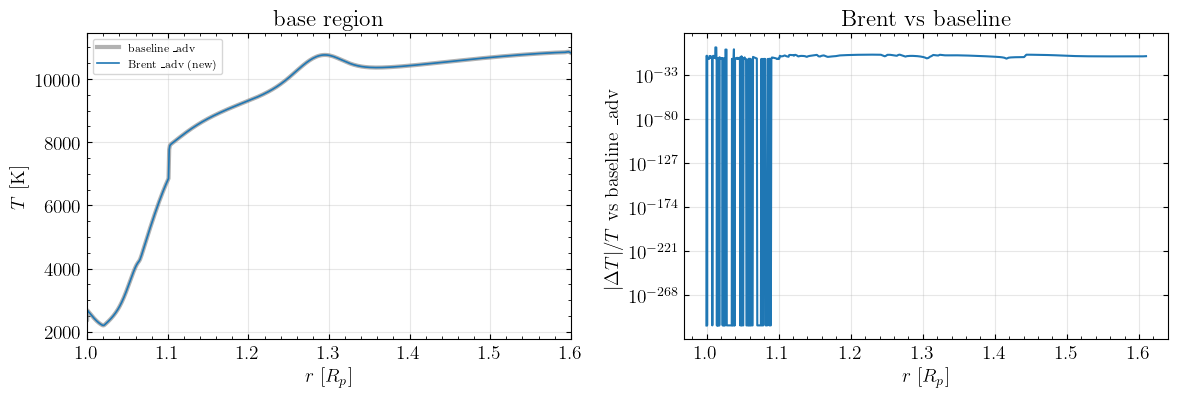

In [4]:
hn = hydro('newton', adv=True); hb = hydro('baseline', adv=True)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(hb['r'], hb['T'], color='0.5', lw=3, alpha=0.6, label='baseline _adv')
ax[0].plot(hn['r'], hn['T'], 'tab:blue', lw=1.2, label='Brent _adv (new)')
ax[0].set_ylabel(r'$T$ [K]'); ax[0].set_xlim(1, 1.6); ax[0].set_title('base region')
ax[0].legend(fontsize=8)
nn = min(len(hn['r']), len(hb['r']))
rel = np.abs(hn['T'][:nn]-hb['T'][:nn])/np.maximum(hb['T'][:nn],1.0)
ax[1].semilogy(hn['r'][:nn], rel+1e-300)
ax[1].set_ylabel(r'$|\Delta T|/T$ vs baseline _adv'); ax[1].set_title('Brent vs baseline')
for a in ax:
    a.set_xlabel(r'$r$ [$R_p$]'); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()